<a href="https://colab.research.google.com/github/nichmars/Johnson-Center-GVSU-Final-Project/blob/main/k_nearest_neighbors.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files
import io
import pandas as pd
import numpy as np
import sklearn.model_selection
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler

from google.colab import drive
drive.mount('/content/drive')
file_name = '/content/drive/MyDrive/MTH498 Project/Filtered Data with Subtypes Again.xlsx'

df = pd.read_excel(file_name)

df.replace('Single Issue', 'Single Issue Charity', inplace=True)

Mounted at /content/drive


In [ ]:
from sklearn.model_selection import train_test_split

metrics = ["Accounts", "Contributions", "Grants", "Assets"]

# Split EINs into train/test
unique_eins = df["ein"].unique()

train_eins, test_eins = train_test_split(
    unique_eins,
    test_size=0.25,
    random_state=42
)

train_df = df[df["ein"].isin(train_eins)].copy()
test_df = df[df["ein"].isin(test_eins)].copy()

print(df.to_string())

Dataframe has 9023 rows

Training set has 6816

Test set has 2207

Things to test:


*   scaled vs. unscaled groupings
*   different number of groupings
* sorting into quartiles by numerical values
* removing "year" as one of the predictor variables
* weighing type and subtype more heavily
* create visualization of the clustering!!!
* should go back and test this on Johnson Center's method

In [ ]:
# List of metrics we want to analyze
metrics = ["Accounts", "Contributions", "Grants", "Assets"]

# Calculate the difference in years for each 'ein' to check for consecutive years
train_df = train_df.sort_values(["ein", "Year"])
train_df["year_diff"] = train_df.groupby("ein")["Year"].diff()

test_df = test_df.sort_values(["ein", "Year"])
test_df["year_diff"] = test_df.groupby("ein")["Year"].diff()

df = df.sort_values(["ein", "Year"])
df["year_diff"] = df.groupby("ein")["Year"].diff()


# Loop through each metric to calculate percent change
# Use .replace(np.nan, 0) to catch 0/0 errors and manually adjust the percent change to 0
for m in metrics:
    pct_col = f"{m.lower()}_pct_change"
    # df[m] = df[m].replace(0, 1)
    temp_train_df_1 = train_df
    temp_train_df_1[m] = train_df[m].replace(0, 1)

    df[pct_col] = temp_train_df_1.groupby("ein")[m].pct_change().replace(np.nan, 0)
    train_df[pct_col] = temp_train_df_1.groupby("ein")[m].pct_change().replace(np.nan, 0)
    df.loc[df["year_diff"] != 1, pct_col] = None


# Assign each org to a growth quartile bracket per metric, Year, Type, subtype
for m in metrics:
    pct_col = f"{m.lower()}_pct_change"

    # Prepping data for KMeans clustering
    # temp_df = df.drop(columns=['ein', "year_diff"])
    temp_train_df = train_df.sort_values(["Year"])
    temp_train_df = train_df[[m]].copy()
    temp_test_df = test_df[[m]].copy()
    # temp_df = pd.get_dummies(temp_df, columns=['Type', 'subtype'], dtype=int)

    # scaler = StandardScaler()
    # temp_df = scaler.fit_transform(temp_df)  #check to see if grouping is better when scaled vs. unscaled
    #print(temp_df)


    # Actually clustering
    nbrs = NearestNeighbors(n_neighbors=2000, algorithm='ball_tree').fit(temp_train_df)
    distances, indices = nbrs.kneighbors(temp_test_df)

    # Get the percent change values of the neighbors
    neighbor_pct_changes = train_df[pct_col].to_numpy()[indices]

    # Assign the mean percent change to the test dataframe
    test_df[pct_col] = neighbor_pct_changes.mean(axis=1)

    # # Splitting data into groups by numerical value:
    # df[f'{m.lower()}_group'] = pd.qcut(df[m], q=250, labels=False, duplicates='drop')

# Assigning new groupings to the same dataframe
# df = df.merge(train_df, on=["ein", "Year", "Accounts", "Contributions", "Grants", "Assets", "Type", "subtype"], how="left")
# df = df.merge(test_df, on=["ein", "Year", "Accounts", "Contributions", "Grants", "Assets", "Type", "subtype", "accounts_group", "contributions_group", "grants_group", "assets_group"], how="left")

# Combine train and test group assignments
groups_df = pd.concat([
    train_df.filter(regex='_group$'),
    test_df.filter(regex='_group$')
]).sort_index()

# Merge back to original df
df = df.join(groups_df)

#print(test_df)
#print(df.to_string())
# df['contributions_pct_change'].count()
# df.columns
#print(train_df[f"{m.lower()}_group"].value_counts())
#print(test_df[f"{m.lower()}_group"].value_counts())
test_df


,ein,Year,Accounts,Contributions,Grants,Assets,Type,subtype,year_diff,accounts_pct_change,contributions_pct_change,grants_pct_change,assets_pct_change
33,10564355,2007,117,800333.0,898457,8193595.0,Community Foundation,Community,NaN,0.324135,5697.212077,4521.292177,15012.362095
34,10564355,2008,128,1368198.0,669293,5569861.0,Community Foundation,Community,1.0,0.322342,9362.304974,2631.891484,6943.878430
35,10564355,2009,134,1013136.0,830741,7119020.0,Community Foundation,Community,1.0,0.329530,6477.339473,4521.287595,15012.361669
36,10564355,2010,133,893316.0,1112546,7881597.0,Community Foundation,Community,1.0,0.322741,5697.274439,4417.065110,15012.362569
37,10564355,2011,141,1428208.0,1174712,8963099.0,Community Foundation,Community,1.0,0.335229,10637.899806,5437.950395,15012.369349
...,...,...,...,...,...,...,...,...,...,...,...,...,...
9006,631154984,2008,0,0.0,0,0.0,Community Foundation,Community,1.0,0.095587,759.281243,825.453962,5209.484490
9017,832513160,2022,1,0.0,0,100000.0,Single Issue Charity,Other,NaN,0.095587,759.281243,825.453962,5209.484490
9018,841612422,2007,0,0.0,0,0.0,Single Issue Charity,Other,NaN,0.095587,759.281243,825.453962,5209.484490
9019,841682682,2007,0,0.0,0,0.0,Community Foundation,Community,NaN,0.095587,759.281243,825.453962,5209.484490


In [ ]:
# Predict next year's value using each org's bracket-specific median growth
for m in metrics:
    prev_actual = test_df.groupby("ein")[m].shift(1)
    test_df[f"predicted_{m.lower()}"] = prev_actual * (1 + test_df[f"{m.lower()}_pct_change"])

# Combining predicted columns to the test dataframe
# predicted_df = df.filter(regex='predicted_')
# test_df = test_df.join(predicted_df)
test_df

,ein,Year,Accounts,Contributions,Grants,Assets,Type,subtype,year_diff,accounts_pct_change,contributions_pct_change,grants_pct_change,assets_pct_change,predicted_accounts,predicted_contributions,predicted_grants,predicted_assets
33,10564355,2007,117,800333.0,898457,8193595.0,Community Foundation,Community,NaN,0.324135,5697.212077,4521.292177,15012.362095,NaN,NaN,NaN,NaN
34,10564355,2008,128,1368198.0,669293,5569861.0,Community Foundation,Community,1.0,0.322342,9362.304974,2631.891484,6943.878430,154.714020,7.493762e+09,2.365540e+09,5.690352e+10
35,10564355,2009,134,1013136.0,830741,7119020.0,Community Foundation,Community,1.0,0.329530,6477.339473,4521.287595,15012.361669,170.179783,8.863651e+09,3.026735e+09,8.362234e+10
36,10564355,2010,133,893316.0,1112546,7881597.0,Community Foundation,Community,1.0,0.322741,5697.274439,4417.065110,15012.362569,177.247324,5.773127e+09,3.670268e+09,1.068804e+11
37,10564355,2011,141,1428208.0,1174712,8963099.0,Community Foundation,Community,1.0,0.335229,10637.899806,5437.950395,15012.369349,177.585479,9.503899e+09,6.051083e+09,1.183293e+11
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9006,631154984,2008,0,0.0,0,0.0,Community Foundation,Community,1.0,0.095587,759.281243,825.453962,5209.484490,0.000000,0.000000e+00,0.000000e+00,0.000000e+00
9017,832513160,2022,1,0.0,0,100000.0,Single Issue Charity,Other,NaN,0.095587,759.281243,825.453962,5209.484490,NaN,NaN,NaN,NaN
9018,841612422,2007,0,0.0,0,0.0,Single Issue Charity,Other,NaN,0.095587,759.281243,825.453962,5209.484490,NaN,NaN,NaN,NaN
9019,841682682,2007,0,0.0,0,0.0,Community Foundation,Community,NaN,0.095587,759.281243,825.453962,5209.484490,NaN,NaN,NaN,NaN


find error for only test data

In [ ]:
# Convert predicted columns to numeric and replace invalid values
pred_cols = ["predicted_accounts", "predicted_contributions", "predicted_grants", "predicted_assets"]

for col in pred_cols:
    df[col] = pd.to_numeric(test_df[col], errors="coerce")

df = df.replace([np.inf, -np.inf], np.nan)

# Function to calculate Median Relative Deviation
def MRD(actual_col, predicted_col):
    valid_rows = df[df[predicted_col].notna() &
                    df[actual_col].notna() &
                    (df[actual_col] != 0) &
                    (df["year_diff"] == 1)]
    total_actual = valid_rows[actual_col]
    total_predicted = valid_rows[predicted_col]
    RE = (abs((total_actual - total_predicted)) / total_actual).median()
    return RE

def mean_relative_error(actual_col, predicted_col):
    valid_rows = df[df[predicted_col].notna() & df[actual_col].notna() & (df[actual_col] != 0) & (df["year_diff"] == 1)]
    total_actual = valid_rows[actual_col]
    total_predicted = valid_rows[predicted_col]
    RE = (abs((total_actual - total_predicted))/total_actual).mean()
    return RE

def smape(actual_col, predicted_col):
    valid_rows = df[
        df[predicted_col].notna() &
        df[actual_col].notna() &
        (df["year_diff"] == 1)
    ]

    A = valid_rows[actual_col]
    P = valid_rows[predicted_col]

    return np.mean(np.abs(A - P) / ((np.abs(A) + np.abs(P)) / 2))

# Compute relative errors
RE_account = MRD("Accounts", "predicted_accounts")
RE_contributions = MRD("Contributions", "predicted_contributions")
RE_grants = MRD("Grants", "predicted_grants")
RE_assets = MRD("Assets", "predicted_assets")

Mean_account = mean_relative_error("Accounts", "predicted_accounts")
Mean_contributions = mean_relative_error("Contributions", "predicted_contributions")
Mean_grants = mean_relative_error("Grants", "predicted_grants")
Mean_assets = mean_relative_error("Assets", "predicted_assets")

smape_account = smape("Accounts", "predicted_accounts")
smape_contributions = smape("Contributions", "predicted_contributions")
smape_grants = smape("Grants", "predicted_grants")
smape_assets = smape("Assets", "predicted_assets")

print("Median Relative Deviation - Account:", abs(RE_account))
print("Median Relative Deviation - Contributions:", abs(RE_contributions))
print("Median Relative Deviation - Grants:", abs(RE_grants))
print("Median Relative Deviation - Assets:", abs(RE_assets))

print("")
print("Mean Relative Deviation - Account:", abs(Mean_account))
print("Mean Relative Deviation - Contributions:", abs(Mean_contributions))
print("Mean Relative Deviation - Grants:", abs(Mean_grants))
print("Mean Relative Deviation - Assets:", abs(Mean_assets))

print("")
print("SMAPE - Account:", abs(smape_account))
print("SMAPE - Contributions:", abs(smape_contributions))
print("SMAPE - Grants:", abs(smape_grants))
print("SMAPE - Assets:", abs(smape_assets))

Median Relative Deviation - Account: 0.17962956156430893
Median Relative Deviation - Contributions: 6271.7539038087725
Median Relative Deviation - Grants: 3185.3494561239945
Median Relative Deviation - Assets: 9702.402081802242

Mean Relative Deviation - Account: 0.3052817320051618
Mean Relative Deviation - Contributions: 14823.534305912706
Mean Relative Deviation - Grants: 5979.171493196419
Mean Relative Deviation - Assets: 15118.624419378773

SMAPE - Account: 0.22755553191581557
SMAPE - Contributions: 1.9962281165784295
SMAPE - Grants: 1.9967768470023557
SMAPE - Assets: 1.9994067350213052


In [ ]:
#df.to_excel("output.xlsx", index=False)

In [ ]:
df["Actual Error Accounts"] = -(df["Accounts"] - df["predicted_accounts"])/df["Accounts"]
df["Actual Error Contributions"] = -(df["Contributions"] - df["predicted_contributions"])/df["Contributions"]
df["Actual Error Grants"] = -(df["Grants"] - df["predicted_grants"])/df["Grants"]
df["Actual Error Assets"] = -(df["Assets"] - df["predicted_assets"])/df["Assets"]

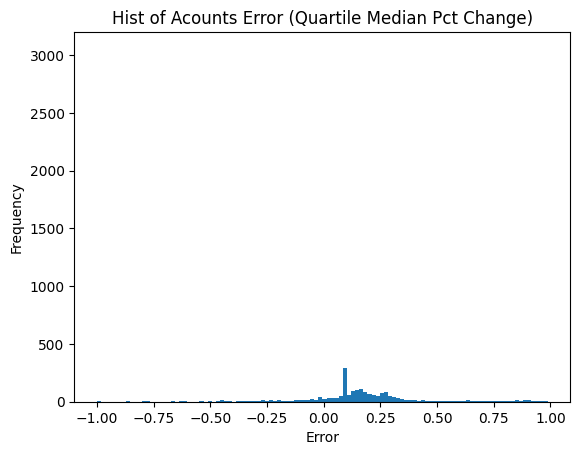

In [ ]:
import matplotlib.pyplot as plt

df_error_accounts = df[~np.isinf(df['Actual Error Accounts'])]
cleaned_errors_accounts = [x for x in df_error_accounts['Actual Error Accounts'] if not np.isnan(x) and x < 1 ]

#print(cleaned_errors_accounts)

plt.hist(cleaned_errors_accounts, bins = 110)

plt.title("Hist of Acounts Error (Quartile Median Pct Change)")
plt.ylabel("Frequency")
plt.xlabel("Error")
plt.ylim(0, 3200) #
plt.show()

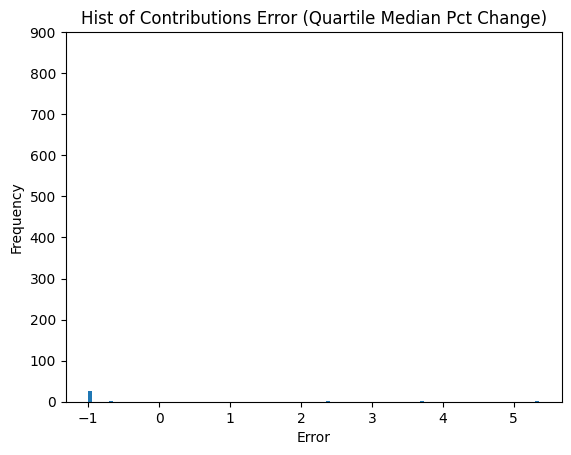

In [ ]:
df_error_contributions = df[~np.isinf(df['Actual Error Contributions'])]
cleaned_errors_contributions = [x for x in df_error_contributions['Actual Error Contributions'] if not np.isnan(x) and x < 6 ]

#print(cleaned_errors_contributions)

plt.hist(cleaned_errors_contributions, bins = 110)

plt.title("Hist of Contributions Error (Quartile Median Pct Change)")
plt.ylabel("Frequency")
plt.xlabel("Error")
plt.ylim(0, 900) #
plt.show()

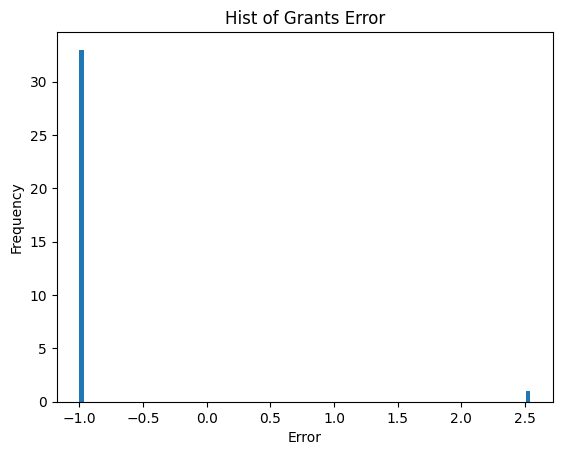

In [ ]:
df_error_grants = df[~np.isinf(df['Actual Error Grants'])]
cleaned_errors_grants = [x for x in df_error_grants['Actual Error Grants'] if not np.isnan(x) and x < 4 ]

#print(cleaned_errors_grants)

plt.hist(cleaned_errors_grants, bins = 110)

plt.title("Hist of Grants Error")
plt.ylabel("Frequency")
plt.xlabel("Error")
plt.show()

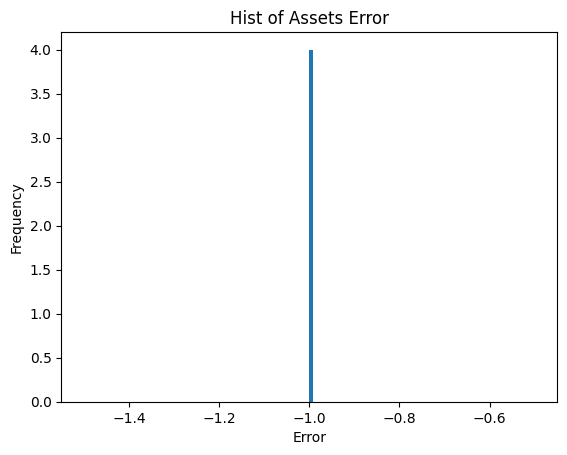

In [ ]:
df_error_assets = df[~np.isinf(df['Actual Error Assets'])]
cleaned_errors_assets = [x for x in df_error_assets['Actual Error Assets'] if not np.isnan(x) and x < 1 ]

#print(cleaned_errors_assets)

plt.hist(cleaned_errors_assets, bins = 110)

plt.title("Hist of Assets Error")
plt.ylabel("Frequency")
plt.xlabel("Error")
plt.show()

/tmp/ipykernel_572/4129015181.py:5: RuntimeWarning: invalid value encountered in scalar divide
  RE = abs((total_actual - total_predicted)).sum() / len(total_actual)
/tmp/ipykernel_572/4129015181.py:5: RuntimeWarning: invalid value encountered in scalar divide
  RE = abs((total_actual - total_predicted)).sum() / len(total_actual)
/tmp/ipykernel_572/4129015181.py:5: RuntimeWarning: invalid value encountered in scalar divide
  RE = abs((total_actual - total_predicted)).sum() / len(total_actual)
/tmp/ipykernel_572/4129015181.py:5: RuntimeWarning: invalid value encountered in scalar divide
  RE = abs((total_actual - total_predicted)).sum() / len(total_actual)


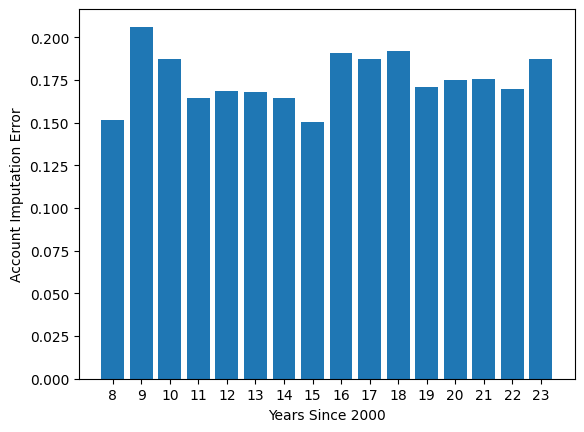

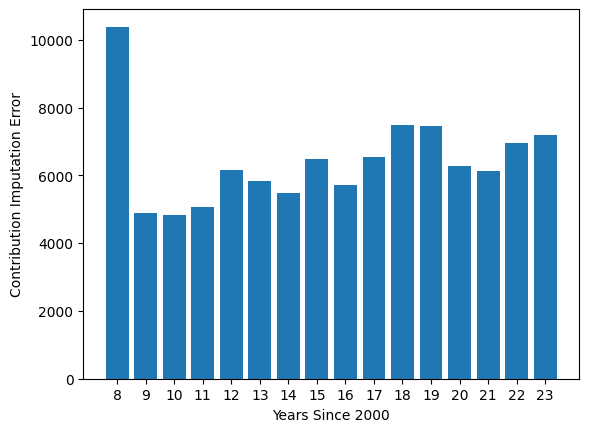

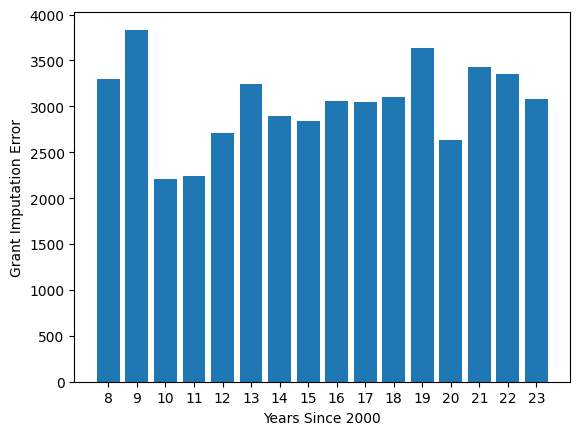

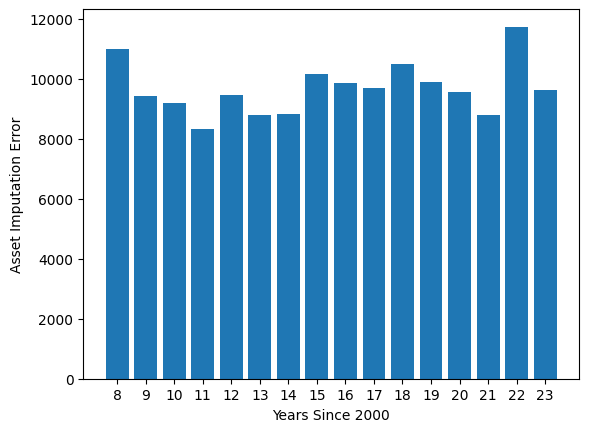

In [ ]:
def relative_grouped_error(actual_col, predicted_col):
    valid_rows = group[group[predicted_col].notna()&group[actual_col].notna()&(group[actual_col] !=0)]
    total_actual = valid_rows[actual_col]
    total_predicted = valid_rows[predicted_col]
    RE = abs((total_actual - total_predicted)).sum() / len(total_actual)
    ME =(abs((total_actual - total_predicted)/total_actual)).median()
    return ME

RE_account_by_year = []
RE_contributions_by_year = []
RE_grants_by_year = []
RE_assets_by_year = []

grouped = df.groupby("Year")
for year, group in grouped:
    RE_account_by_year.append(relative_grouped_error("Accounts", "predicted_accounts"))
    RE_contributions_by_year.append(relative_grouped_error("Contributions", "predicted_contributions"))
    RE_grants_by_year.append(relative_grouped_error("Grants", "predicted_grants"))
    RE_assets_by_year.append(relative_grouped_error("Assets", "predicted_assets"))

# def relative_grouped_error(actual_col, predicted_col):
#     valid_rows = group[group[predicted_col].notna()]
#     total_actual = valid_rows[actual_col].sum()
#     total_predicted = valid_rows[predicted_col].sum()
#     RE = abs((total_actual - total_predicted) / total_actual)
#     return RE

community_account_by_year = []
community_contributions_by_year = []
community_grants_by_year = []
community_assets_by_year = []

national_account_by_year = []
national_contributions_by_year = []
national_grants_by_year = []
national_assets_by_year = []

single_account_by_year = []
single_contributions_by_year = []
single_grants_by_year = []
single_assets_by_year = []

community_df = df[df["Type"] == "Community Foundation"]
cgroups = community_df.groupby("subtype")
for subtype, group in cgroups:
    community_account_by_year.append(relative_grouped_error("Accounts", "predicted_accounts"))
    community_contributions_by_year.append(relative_grouped_error("Contributions", "predicted_contributions"))
    community_grants_by_year.append(relative_grouped_error("Grants", "predicted_grants"))
    community_assets_by_year.append(relative_grouped_error("Assets", "predicted_assets"))

national_df = df[df["Type"] == "National"]
ngroups = national_df.groupby("subtype")
for subtype, group in ngroups:
    national_account_by_year.append(relative_grouped_error("Accounts", "predicted_accounts"))
    national_contributions_by_year.append(relative_grouped_error("Contributions", "predicted_contributions"))
    national_grants_by_year.append(relative_grouped_error("Grants", "predicted_grants"))
    national_assets_by_year.append(relative_grouped_error("Assets", "predicted_assets"))

single_df = df[df["Type"] == "Single Issue Charity"]
sgroups = single_df.groupby("subtype")
for subtype, group in sgroups:
    single_account_by_year.append(relative_grouped_error("Accounts", "predicted_accounts"))
    single_contributions_by_year.append(relative_grouped_error("Contributions", "predicted_contributions"))
    single_grants_by_year.append(relative_grouped_error("Grants", "predicted_grants"))
    single_assets_by_year.append(relative_grouped_error("Assets", "predicted_assets"))
#2024 is discounted from these graphs because the error is exponentially greater than the rest
#2020/2021 was Covid, 2014 was when the stock market rebounded, and 2008/2009 was an economic recession
account_error_by_year = RE_account_by_year[1:-1]
contribution_error_by_year = RE_contributions_by_year[1:-1]
grant_error_by_year = RE_grants_by_year[1:-1]
asset_error_by_year = RE_assets_by_year[1:-1]

Year = range(7, 23)

plt.bar(Year, account_error_by_year)
plt.xlabel("Years Since 2000")
plt.ylabel("Account Imputation Error")
plt.xticks(Year, [str(i+1) for i in Year])
plt.show()

plt.bar(Year, contribution_error_by_year)
plt.xlabel("Years Since 2000")
plt.ylabel("Contribution Imputation Error")
plt.xticks(Year, [str(i+1) for i in Year])
plt.show()

plt.bar(Year, grant_error_by_year)
plt.xlabel("Years Since 2000")
plt.ylabel("Grant Imputation Error")
plt.xticks(Year, [str(i+1) for i in Year])
plt.show()

plt.bar(Year, asset_error_by_year)
plt.xlabel("Years Since 2000")
plt.ylabel("Asset Imputation Error")
plt.xticks(Year, [str(i+1) for i in Year])
plt.show()